<a href="https://colab.research.google.com/github/Goyallgithub/smaresseachpaper/blob/main/ReseachpaperSocialMedia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Optimizing Random Forest parameters...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/tmp/ipykernel_7579/1880721223.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


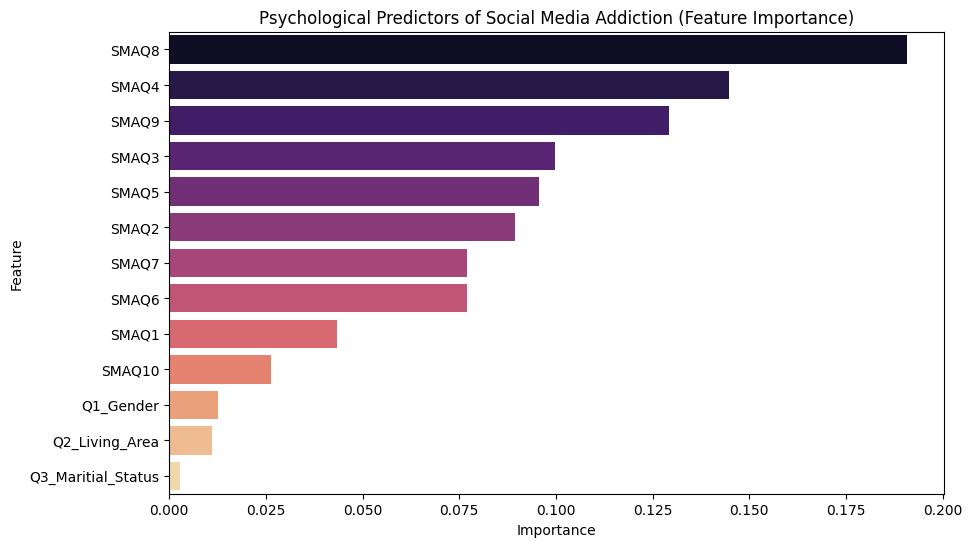

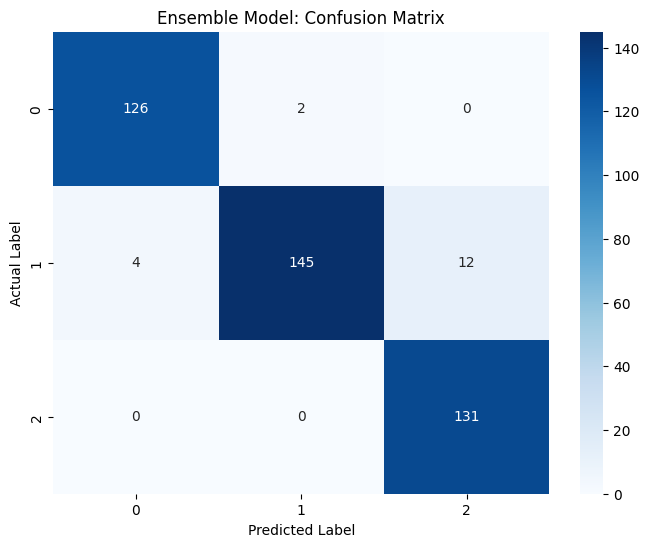

Ensemble Accuracy: 0.9571

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       128
           1       0.99      0.90      0.94       161
           2       0.92      1.00      0.96       131

    accuracy                           0.96       420
   macro avg       0.96      0.96      0.96       420
weighted avg       0.96      0.96      0.96       420



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# 1. Load and Clean
df = pd.read_csv('SMA.csv')
X = df.drop(['SMA_Scale_value', 'SMA_Scale (Class_Lebel)'], axis=1)
y = df['SMA_Scale (Class_Lebel)'] - 1 # Zero-indexing for XGBoost

# 2. Advanced Preprocessing
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Hyperparameter Tuning for the Best Model (Random Forest)
print("Optimizing Random Forest parameters...")
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid_search.fit(X_train_scaled, y_train)
best_rf = grid_search.best_estimator_

# 4. Creating a Hybrid Ensemble (Voting Classifier)
# This combines RF, XGB, and SVM into one "Super Model"
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
svm = SVC(probability=True)

ensemble_model = VotingClassifier(
    estimators=[('rf', best_rf), ('xgb', xgb), ('svm', svm)],
    voting='soft'
)
ensemble_model.fit(X_train_scaled, y_train)

# 5. Feature Importance - This is your "Research Gold"
importances = best_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# --- VISUALIZATIONS FOR PAPER ---

# Plot 1: Feature Importance (The "Why")
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Psychological Predictors of Social Media Addiction (Feature Importance)')
plt.savefig('feature_importance.png')
plt.show()

# Plot 2: Confusion Matrix for Ensemble
y_pred = ensemble_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Ensemble Model: Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png')
plt.show()

# Final Metrics
print(f"Ensemble Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

In [4]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(ensemble_model, X_res, y_res, cv=5)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:37:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:37:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:37:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:37:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Mean CV Accuracy: 0.9733 (+/- 0.0334)


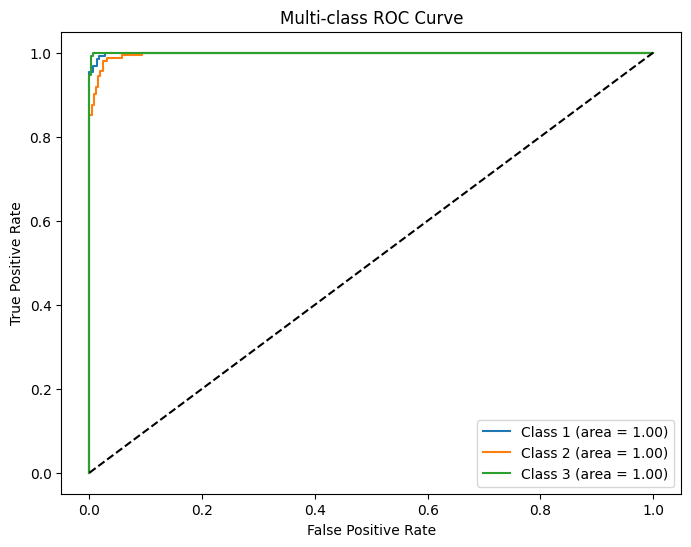

In [5]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = ensemble_model.predict_proba(X_test_scaled)

plt.figure(figsize=(8, 6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {i+1} (area = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend()
plt.savefig('ROC_Curve.png')
plt.show()